<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc" style="margin-top: 1em;"><ul class="toc-item"></ul></div>

In [7]:
import numpy as np
from numpy import r_
import scipy as sp
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure,plot,imshow
from matplotlib.colors import LogNorm
import time #for timing
from tqdm import tqdm
import matplotlib as mpl
mpl.rcParams['image.origin']='lower'
mpl.rcParams['image.cmap']='viridis'
mpl.rcParams['image.interpolation']='none'
mpl.rcParams['figure.max_open_warning']=40

In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
%run -i pstorage/scan-rate-p0004-1.des.py

[]


<Figure size 640x480 with 0 Axes>

In [10]:
from pyanal.summarize import *

In [11]:
avgimg,frnos,Is=summarize(DD)

Using pstorage/results/scan-rate-p0004-1-avgimg-1-1000.npz


/tmp/ipykernel_10176/2589609311.py:3: RuntimeWarning: divide by zero encountered in log
  imshow(np.log(avgimg*DD.DD['mask']))


(1000.0, 1200.0)

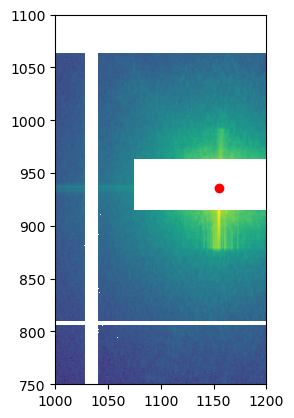

In [59]:
# img=DD.FD.rdframe(1)
figure()
imshow(np.log(avgimg*DD.DD['mask']))
plot(DD.DD['xbar'],DD.DD['ybar'],'ro')
plt.ylim(750,1100)
plt.xlim(1000,1200)

In [15]:
# with open(\
#     DD.DD['pdir']+DD.DD['cdir']+\
#     'uid=9d2c20af_md.pkl.pkl',\
#     "rb") as f:
#     a=pkl.load(f)
#     print(a["beam_center_x"],a["beam_center_y"])
#     print(a['number of images_'])
#     DD.DD["ybar"],DD.DD["xbar"]=a["beam_center_x"],a["beam_center_y"]
#     mask=a["mask"]
#     bad_frame_list=a["bad_frame_list"]
#     del a
print(DD.DD["xbar"],DD.DD["ybar"])

1155 936


140277.58445945947 53580163.17887885
0.01


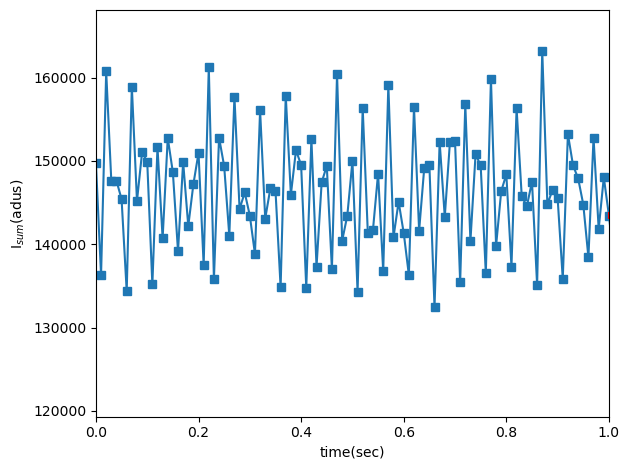

In [64]:
figure()
dy=np.sqrt(Is)
plt.errorbar(np.arange(len(Is))*DD.DD['preset_period'],Is,yerr=np.sqrt(Is),\
             marker='s',errorevery=100,ecolor='red',barsabove=True)
# plt.fill_between(np.arange(len(Is))*DD.DD['preset_period'],Is-dy,Is+dy,alpha=1.)
# plot(np.arange(len(Is))*DD.DD['preset_period'],Is,alpha=.2)
if len(bad_frame_list)>0 : plt.plot(bad_frame_list*DD.DD['preset_period'],Is[bad_frame_list],'ro') #??? doesn't work
plt.xlabel("time(sec)")
plt.ylabel("I$_{sum}$(adus)")
print(np.mean(Is[112:]),np.var(Is[112:],ddof=1))
print(DD.DD['preset_period'])
plt.xlim(0,1)
plt.tight_layout()

In [34]:
qperpixel=4*np.pi*DD.DD['energy']/12.398*DD.DD['dpix']/DD.DD['rdet']/2.0
print(qperpixel)
DD.DD

3.0327933494821545e-05


{'pdir': '/nsls2/data/chx/legacy/analysis/2024_1/leheny/',
 'cdir': 'rawdata/',
 'firstfile': 1,
 'filename': 'uid_fc18facc-302b-462a-8973-8687f66fc669.cmp',
 'FOUT': 'scan-rate-p0004-1',
 'ybar': 936,
 'xbar': 1155,
 'numberfiles': 1000,
 'detector': 'Eiger-4M',
 'dpix': 0.075,
 'mask': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 1., ..., 1., 1., 0.],
        [0., 1., 1., ..., 1., 1., 0.],
        ...,
        [0., 1., 1., ..., 1., 1., 0.],
        [0., 1., 1., ..., 1., 1., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 'ccdroi': [1, 2070, 2167],
 'rows': 2167,
 'cols': 2070,
 'energy': 12.793566761288591,
 'rdet': 16033.868610000003,
 'compression': 6,
 'preset': 0.009997,
 'preset_period': 0.01,
 'qperpixel': 3.0327933494821545e-05}

(-10.0, 10.0)

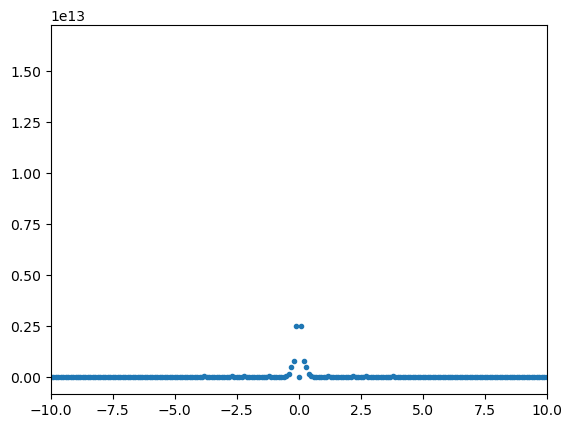

In [62]:
a=Is-np.mean(Is)
f=np.fft.fft(a)
freq=np.fft.fftfreq(len(a),d=.01)
figure()
plt.plot(freq,np.abs(f)**2,'.')
plt.xlim(-10,10)

In [35]:
#get analysis routines, load individually for demonstration
from pyanal.mkphiq import mkphiq
#from pyanal.selectphiq import selectphiq
from pyanal.crosscor import *
from pyanal.ldparts import ldparts
from pyanal.partitions import mkpartlist,partition1d,partition2d
from pyanal.h2t import h2t
from pyanal.avgg2 import avgg2
from pyanal.ciravg import *

import scipy.signal

In [36]:
pixellist,qs,phis=mkphiq(DD,phimin=-5.0)
qplot=np.arange(36,250+1)
print(DD.DD['xbar'],DD.DD['ybar'])
print(DD.DD['rows'],DD.DD['cols'])

nopixels = 4105664 (91.53%)
minimum q =  22.0 maximum q =  1685.869805174765
phi discontinuity is at    -5.0000,  355.0000
minimum phi=  -4.999857491936893 maximum phi 354.99935540244155
1155 936
2167 2070


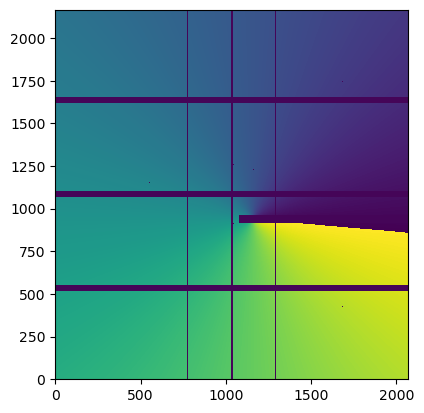

In [37]:
timg=0*avgimg.copy()
timg.ravel()[pixellist]=phis
figure()
imshow(timg)

In [38]:
q,sq,nnn=ciravg(avgimg,pixellist,qs,qplot,numflag=True)

Text(0, 0.5, 'S(Q)')

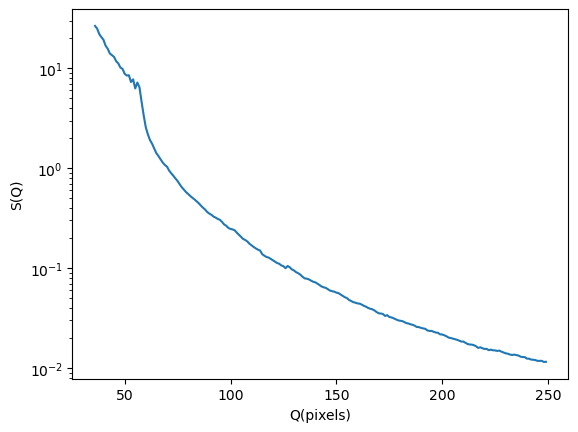

In [39]:
figure()
skip=1
plt.semilogy(q,sq)
plt.xlabel("Q(pixels)")
plt.ylabel("S(Q)")

In [41]:
qlist=mkpartlist(np.linspace(30,250,12))
#philist=mkpartlist(np.linspace(0,360,19))-10
philist=mkpartlist(np.arange(0,360,22.5),width=20)
plist,bind,qbind,phibind,noperbin,inpixellist,binlist,binqlist,binphilist=\
    partition2d(pixellist,qs,qlist,phis,philist)

In [42]:
print(binqlist.shape,binphilist.shape)

(165,) (165,)


In [43]:
Ipix=ldparts(DD.FD,plist)
# Ipix=ldparts(DD.FD,plist,begframe=2500,noframes=2000)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 999/1000 [00:01<00:00, 836.90it/s]


In [44]:
ccs,cts=h2t(Ipix,bind,norm="symmetric",Pcorrect=True,rtncounts=True)

 51%|████████████████████████████████████████████████████████████████▏                                                             | 84/165 [00:00<00:00, 83.86it/s]/nsls2/data/chx/legacy/analysis/2024_1/leheny/pyanal/h2t.py:33: RuntimeWarning: invalid value encountered in divide
  B /= cts
/nsls2/data/chx/legacy/analysis/2024_1/leheny/pyanal/h2t.py:38: RuntimeWarning: divide by zero encountered in divide
  np.fill_diagonal(cor,np.diag(cor)-1/cts)
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 165/165 [00:02<00:00, 74.86it/s]


In [45]:
print(ccs.shape,cts.shape)

(165, 1000, 1000) (1000,)


In [46]:
g2s=np.zeros((len(binqlist),ccs.shape[1]))
print(g2s.shape)
for i in range(len(binqlist)):
    g2s[i,:]=avgg2(ccs[i][:,:])

(165, 1000)


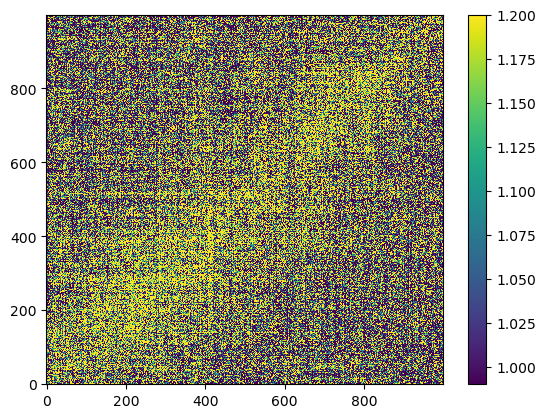

In [48]:
figure()
imshow(ccs[50],vmin=.99,vmax=1.2,aspect='auto')
plt.colorbar()

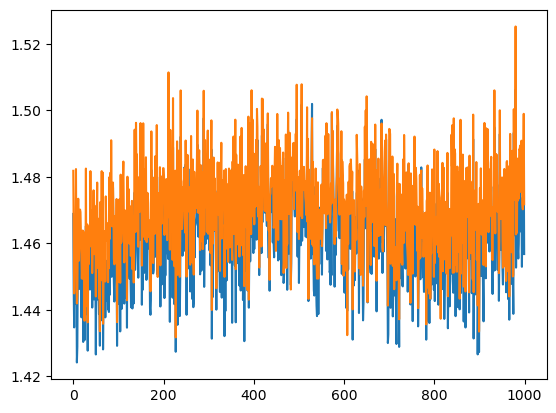

In [49]:
figure()
plot(ccs[2][661,:])
plot(ccs[2][735,:])

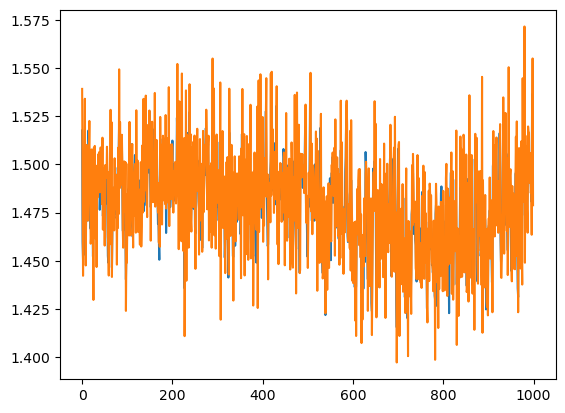

In [50]:
figure()
plot(np.diag(ccs[2],k=1))
plot(np.diag(ccs[2]))

In [51]:
from pyanal.multitau import *

In [53]:
tt,gg=multitau(Ipix,bind,Pcorrect=True)

total time: 10.268875360488892


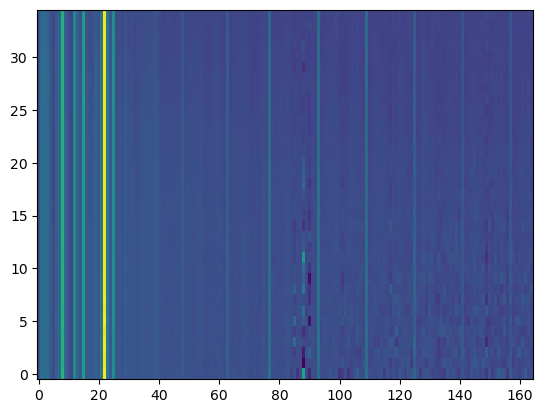

In [54]:
figure()
imshow(gg,aspect='auto')

829.0

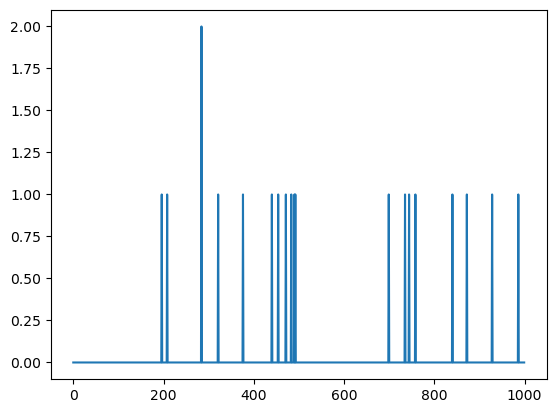

In [55]:
figure()
plot(Ipix[:,9952])
Ipix.max()

(278,)


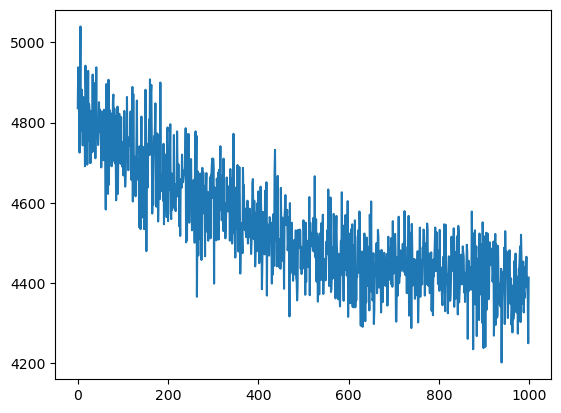

In [56]:
w=np.where(bind==2)[0]
figure()
plot(np.sum(Ipix[:,w],axis=1))
print(w.shape)

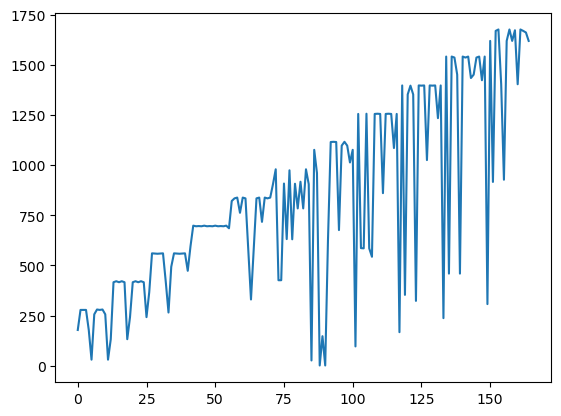

In [57]:
figure()
plot(noperbin)

In [58]:
np.var(np.sum(Ipix,axis=1))/np.mean(np.sum(Ipix,axis=1)),np.var(np.sum(Ipix,axis=1)),np.mean(np.sum(Ipix,axis=1))

(272.5231186956738, 23286266.299279, 85446.939)